In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import statistics

years = range(2019,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 1

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

In [19]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/3,
            'closeness': 1/3,
            'betweenness': 0,
            'eigenvector': 1/3
        }
    
    nodes = list(G.nodes)

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(nx.degree(G, weight="weight"))
    
    # Clustering coefficient
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # Eigenvector centrality
    eig_dict = nx.eigenvector_centrality(G, weight="weight")
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_closeness = normalize_dict(closeness_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_eig = normalize_dict(eig_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores

In [20]:
risk_scores = {}
for year in years:
    print(f"Computing risk scores for {year}...")
    risk_scores[year] = calculate_hybrid_risk_metric(graphs[f"graph_{year}"])

df_long = pd.DataFrame([
    {"year": year, "stock": stock, "risk": score}
    for year, scores in risk_scores.items()
    for stock, score in scores.items()
])

df_wide = df_long.pivot(index="stock", columns="year", values="risk")

df_wide = df_wide.dropna()
print(f"Stocks present in all years: {len(df_wide)}")

Computing risk scores for 2019...
Computing risk scores for 2020...
Computing risk scores for 2021...
Computing risk scores for 2022...
Computing risk scores for 2023...
Computing risk scores for 2024...
Stocks present in all years: 401


In [21]:
# ============================================================
# 2. SUMMARY STATISTICS TABLE
# ============================================================
summary_rows = []
for year in years:
    scores = np.array(list(risk_scores[year].values()))
    summary_rows.append({
        "Year":    year,
        "Mean":    scores.mean(),
        "Median":  np.median(scores),
        "Std":     scores.std(),
        "Skew":    pd.Series(scores).skew(),
        "Kurt":    pd.Series(scores).kurt(),
        "Min":     scores.min(),
        "Max":     scores.max(),
        "Q25":     np.percentile(scores, 25),
        "Q75":     np.percentile(scores, 75),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Year").round(4)
print(summary_df.to_string())
# print("\nLaTeX:\n", summary_df.to_latex())

        Mean  Median     Std    Skew     Kurt     Min     Max     Q25     Q75
Year                                                                         
2019  0.1941  0.1874  0.1147  2.1651  10.5828  0.0006  0.9907  0.1142  0.2512
2020  0.2034  0.1949  0.1134  2.3109  11.3886  0.0000  1.0000  0.1348  0.2545
2021  0.1810  0.1685  0.1073  2.1131  10.5156  0.0001  0.9934  0.1116  0.2357
2022  0.1964  0.1905  0.1206  2.4099  11.8187  0.0010  1.0000  0.1230  0.2515
2023  0.1842  0.1781  0.1116  2.3256  11.7181  0.0010  1.0000  0.1093  0.2361
2024  0.1993  0.1925  0.1098  2.1210  10.2537  0.0005  1.0000  0.1341  0.2480


In [22]:
centralities = ["central", "peripheral"]
portfolios = {}

for year in years:
    for centrality in centralities:
        cols = pd.read_csv(f"../../data/06_portfolios/{centrality}_{year}.csv", index_col="Date").columns.tolist()
        try:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-k}_{year}.parquet")[cols]
        except:
            portfolios[f"{centrality}_{year}"] = pd.read_parquet(f"../../data/02_clean/returns_{year-k+1}_{year}.parquet")[cols]

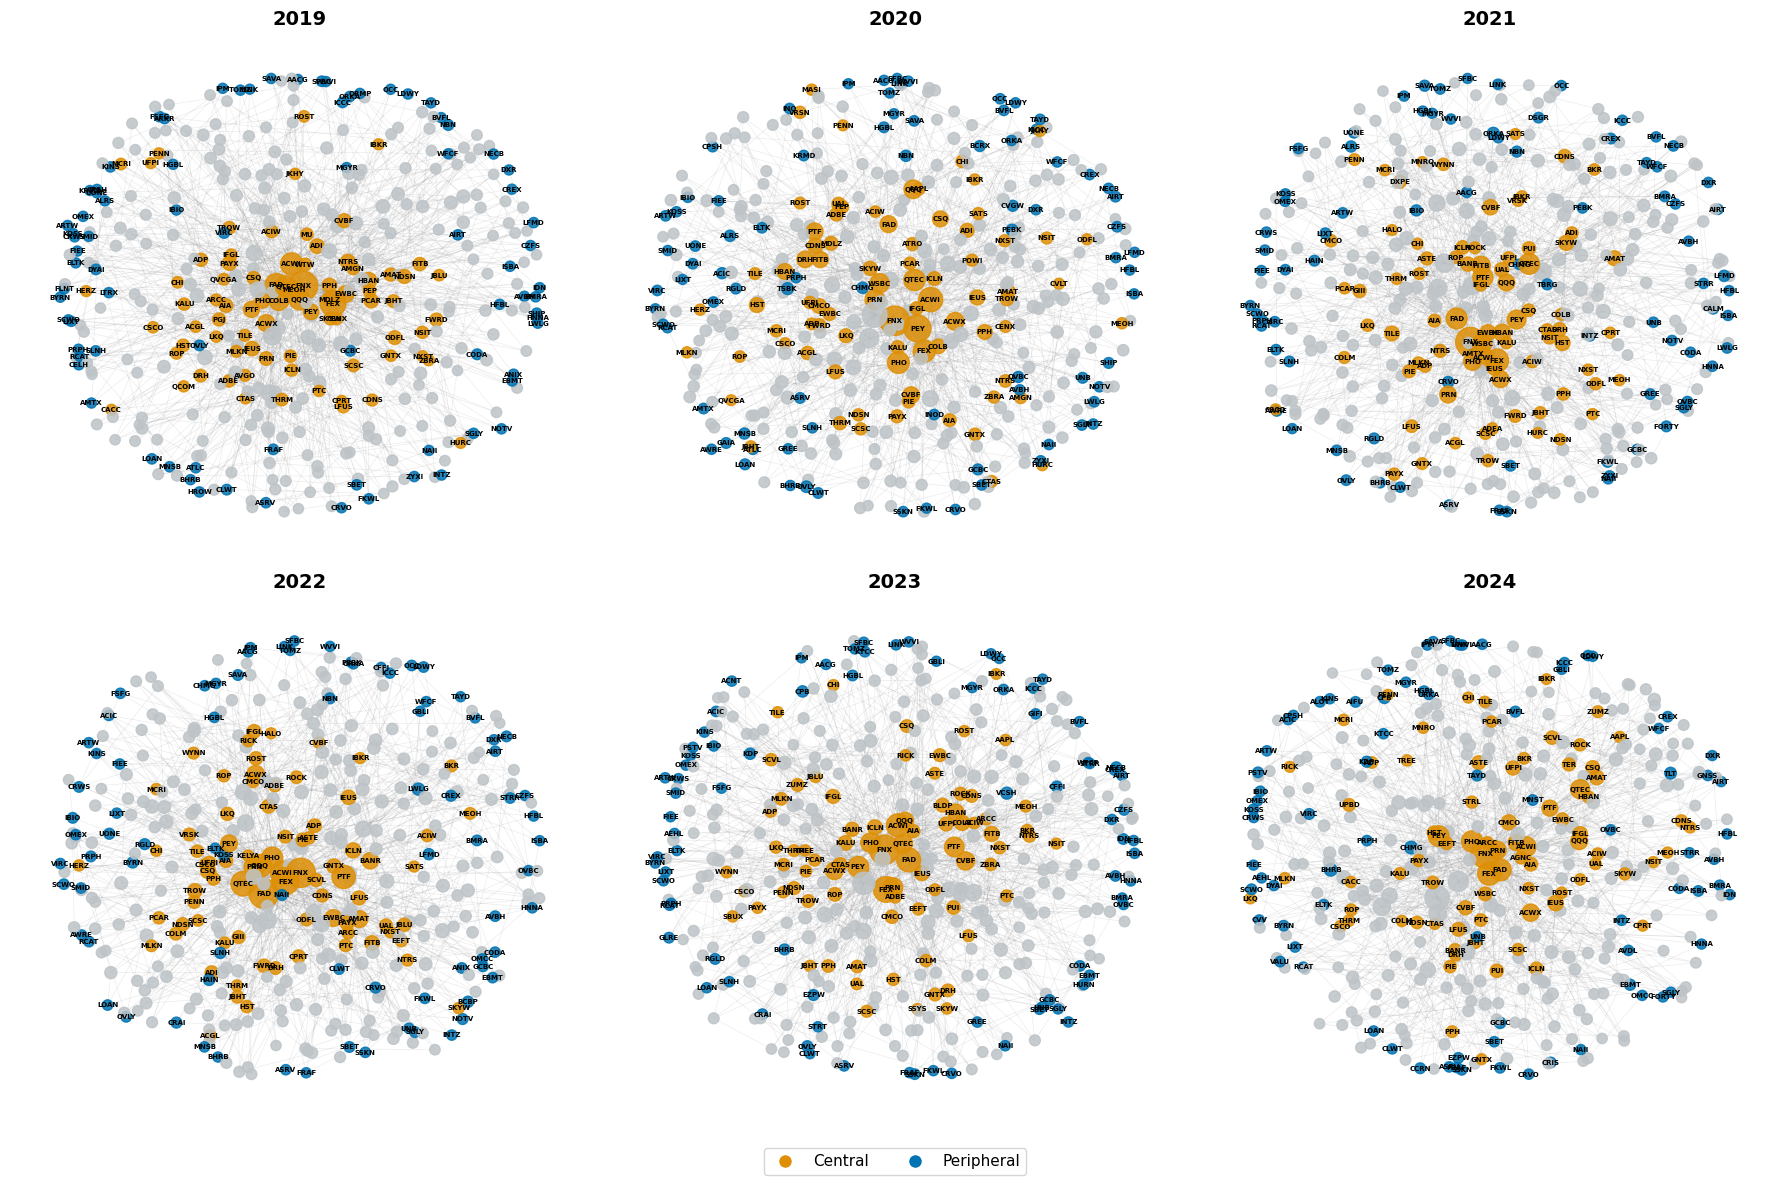

In [23]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}"].columns)

    palette = sns.color_palette("colorblind")

    central_color = palette[1]
    peripheral_color = palette[0]
    middle_color = "#BDC3C7"
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append(central_color)       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append(peripheral_color)       # green = low risk / peripheral
        else:
            node_colors.append(middle_color)       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=14, fontweight="bold")
    ax.axis("off")

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=central_color, markersize=10, label="Central"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=peripheral_color, markersize=10, label="Peripheral"),
    # Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

# fig.suptitle("TMFG Network by Year — Central vs Peripheral Stocks", fontsize=16, fontweight="bold")
os.makedirs(f"../../figures/window_{k}", exist_ok=True)
plt.savefig(f"../../figures/window_{k}/graphs.png", dpi=300)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

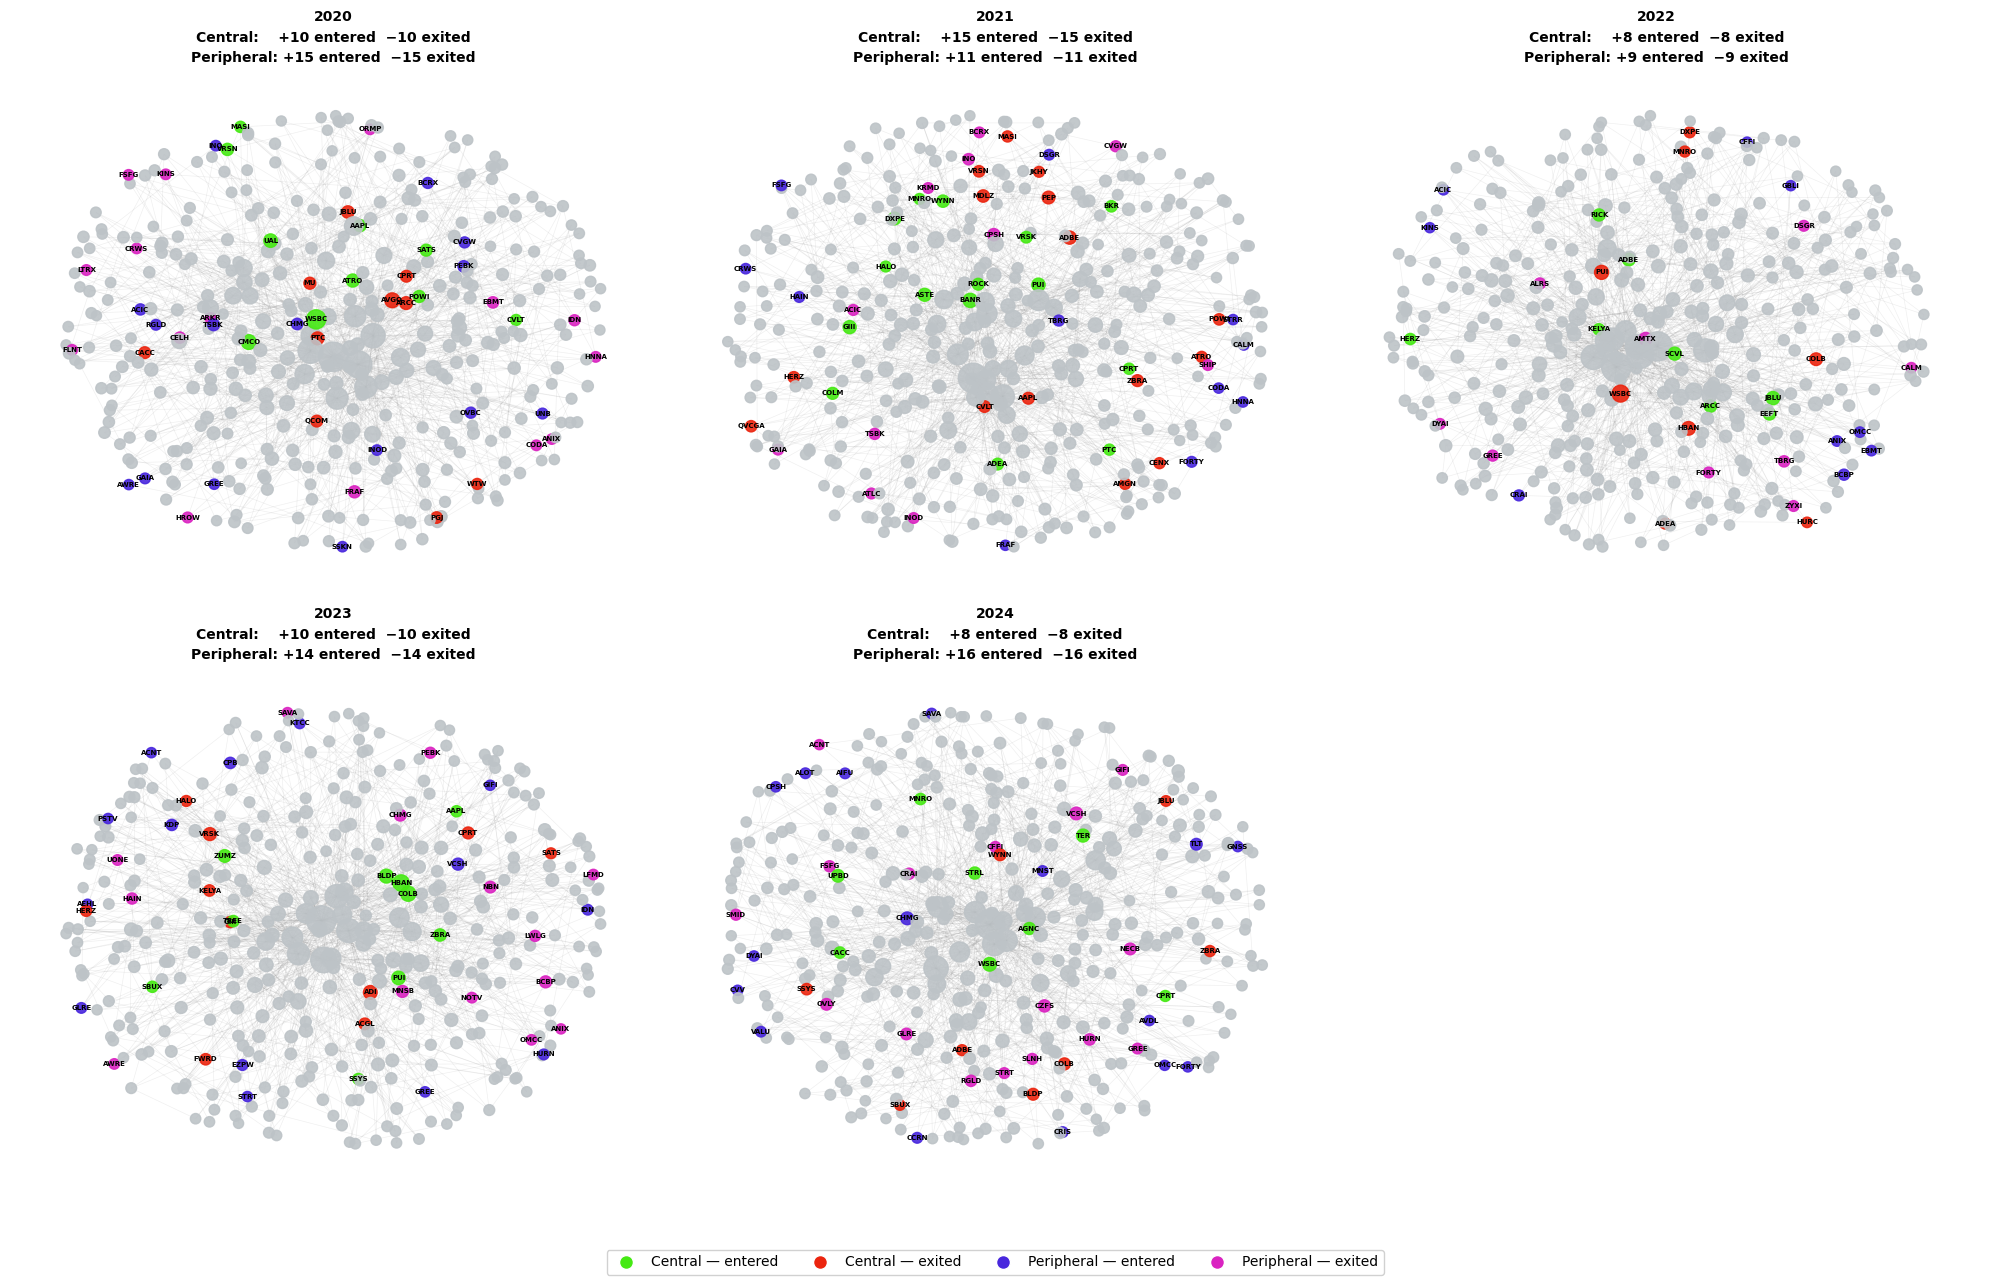

In [19]:
from matplotlib.lines import Line2D

# Precompute turnover sets for each year transition
# For year Y: compare with year Y-1
def get_turnover(portfolios_dict, years):
    """Returns per year: entered, exited, stable sets"""
    turnover = {}
    year_list = sorted(years)
    for i, year in enumerate(year_list):
        curr = set(portfolios_dict[year])
        if i == 0:
            # No previous year — all are "stable"
            turnover[year] = {"entered": set(), "exited": set(), "stable": curr}
        else:
            prev = set(portfolios_dict[year_list[i - 1]])
            turnover[year] = {
                "entered": curr - prev,   # in current, not in previous
                "exited":  prev - curr,   # in previous, not in current
                "stable":  curr & prev    # in both
            }
    return turnover

central_turnover = get_turnover(
    {y: set(portfolios[f"central_{y}"].columns) for y in years},
    years
)

peripheral_turnover = get_turnover(
    {y: set(portfolios[f"peripheral_{y}"].columns) for y in years},
    years
)

# ── Color scheme ──────────────────────────────────────────────────────────────
# Central stable      → dark red
# Central entered     → orange (new in central)
# Central exited      → light red/salmon (left central)
# Peripheral stable   → dark green
# Peripheral entered  → lime (new in peripheral)
# Peripheral exited   → light green (left peripheral)
# Middle              → grey

COLOR = {
    "central_entered":     "#45E913",
    "central_exited":      "#EB240E",
    "peripheral_entered":  "#4827DD",
    "peripheral_exited":   "#DA23C1",
    "middle":              "#BDC3C7",
}

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes.flat[-1].set_visible(False)

for ax, year in zip(axes.flat, range(2020,2025)):
    G = graphs[f"graph_{year}"]

    ct = central_turnover[year]
    pt = peripheral_turnover[year]

    node_colors = []
    for node in G.nodes():
        if   node in ct["entered"]:   node_colors.append(COLOR["central_entered"])
        elif node in ct["exited"]:    node_colors.append(COLOR["central_exited"])
        elif node in ct["stable"]:    node_colors.append(COLOR["middle"])
        elif node in pt["entered"]:   node_colors.append(COLOR["peripheral_entered"])
        elif node in pt["exited"]:    node_colors.append(COLOR["peripheral_exited"])
        elif node in pt["stable"]:    node_colors.append(COLOR["middle"])
        else:                         node_colors.append(COLOR["middle"])

    degree  = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    node_sizes = [50 + 400 * (degree[n] / max_deg) for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.4)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.5, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.9)

    # Label only turnover nodes
    turnover_nodes = ct["entered"] | ct["exited"] | pt["entered"] | pt["exited"]
    labels = {n: n for n in G.nodes() if n in turnover_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    # Subtitle with counts
    title_lines = [
        str(year),
        f"Central:    +{len(ct['entered'])} entered  −{len(ct['exited'])} exited",
        f"Peripheral: +{len(pt['entered'])} entered  −{len(pt['exited'])} exited",
    ]
    ax.set_title("\n".join(title_lines), fontsize=10, fontweight="bold", linespacing=1.6)
    ax.axis("off")

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR["central_entered"],   markersize=10, label="Central — entered"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR["central_exited"],    markersize=10, label="Central — exited"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR["peripheral_entered"],markersize=10, label="Peripheral — entered"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor=COLOR["peripheral_exited"], markersize=10, label="Peripheral — exited"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.01), frameon=True, framealpha=0.9)

# fig.suptitle("TMFG Network — Portfolio Turnover by Year", fontsize=16, fontweight="bold")
plt.savefig(f"../../figures/window_{k}/graphs_turnover.png", dpi=300)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()